# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("sample_data/housing.csv")


In [5]:
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
(20640, 10)
Index(['longitude', 'latitude', 'housing_median_age', 'total_ro

In [6]:
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


# Visualize missing values

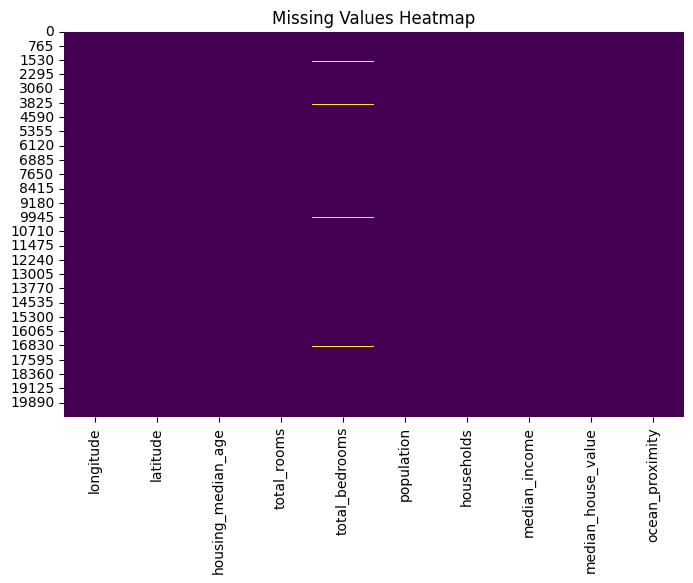

In [7]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [8]:
df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)

/tmp/ipykernel_77244/2164095440.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)


In [9]:
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [10]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [11]:
# Removing duplicates
df.drop_duplicates(inplace=True)

In [12]:
print(df.describe())

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20640.000000  20640.000000  20640.000000   20640.000000   
mean       536.838857   1425.476744    499.539680       3.870671   
std        419.391878   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        297.00000

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


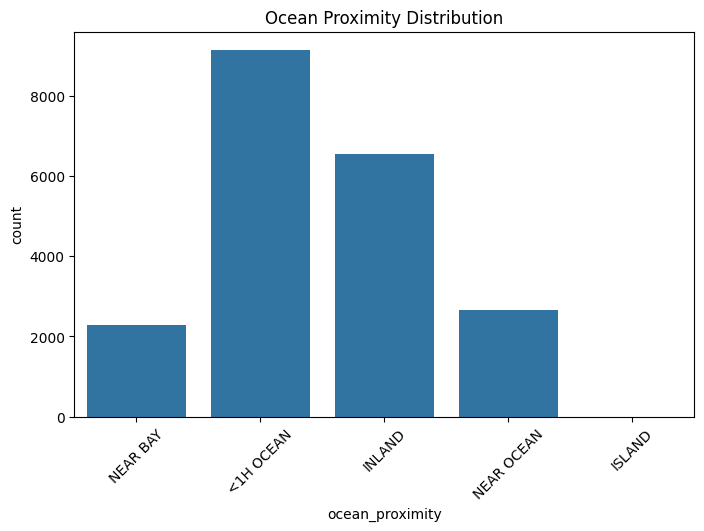

In [13]:
print(df["ocean_proximity"].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="ocean_proximity")
plt.xticks(rotation=45)
plt.title("Ocean Proximity Distribution")
plt.show()


In [14]:
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)


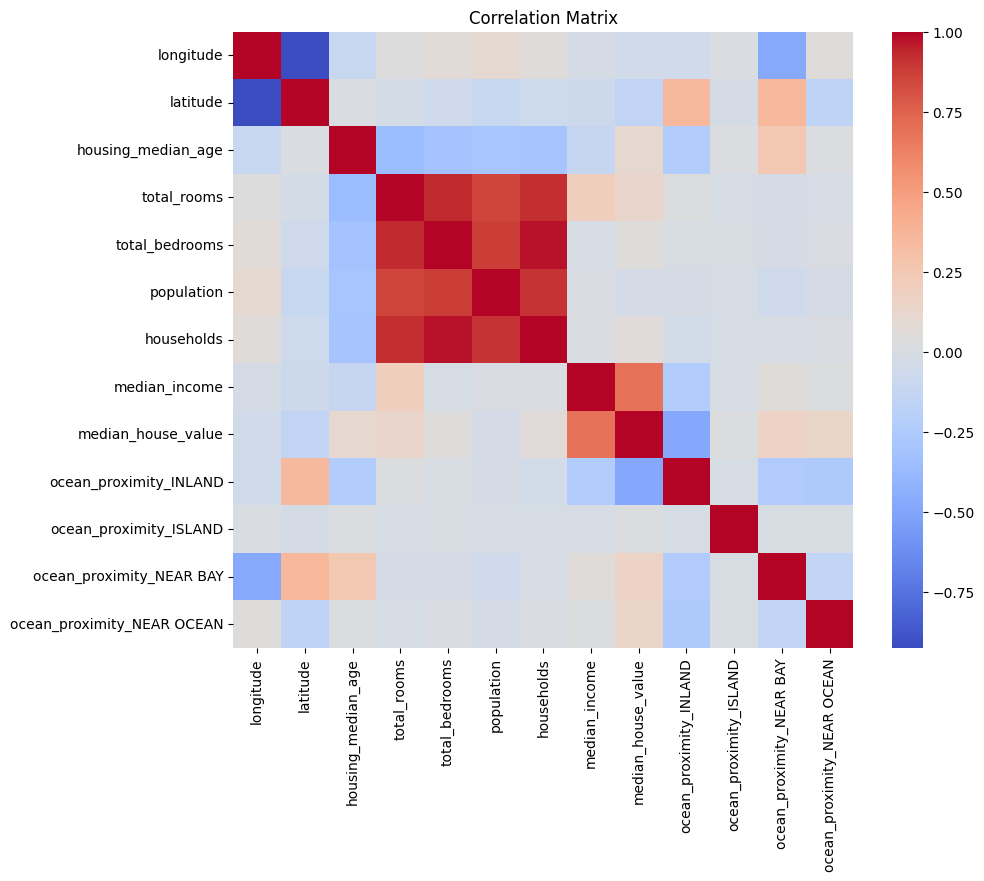

In [15]:
# Correlation Matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

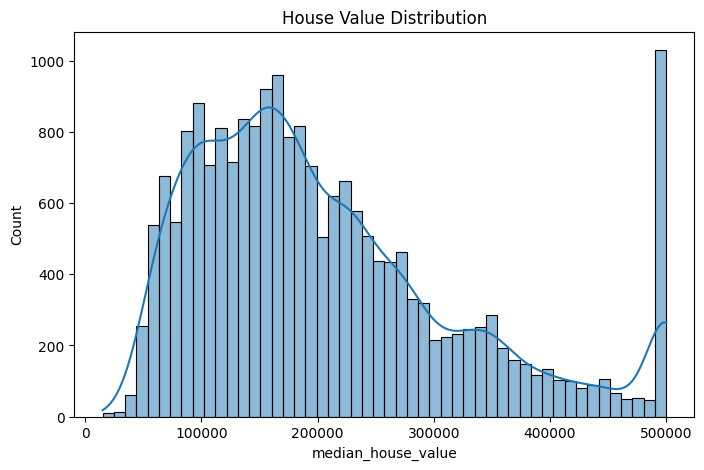

In [16]:
# Distribution of target variable
plt.figure(figsize=(8,5))
sns.histplot(df["median_house_value"], bins=50, kde=True)
plt.title("House Value Distribution")
plt.show()

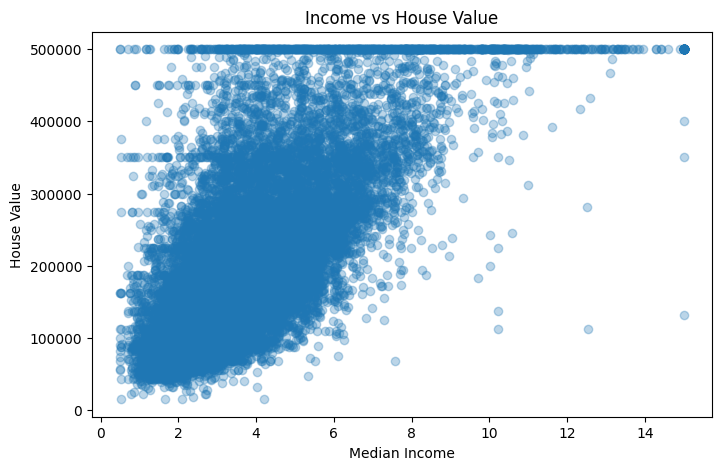

In [17]:
# Income vs House Value
plt.figure(figsize=(8,5))
plt.scatter(df["median_income"], df["median_house_value"], alpha=0.3)
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Income vs House Value")
plt.show()

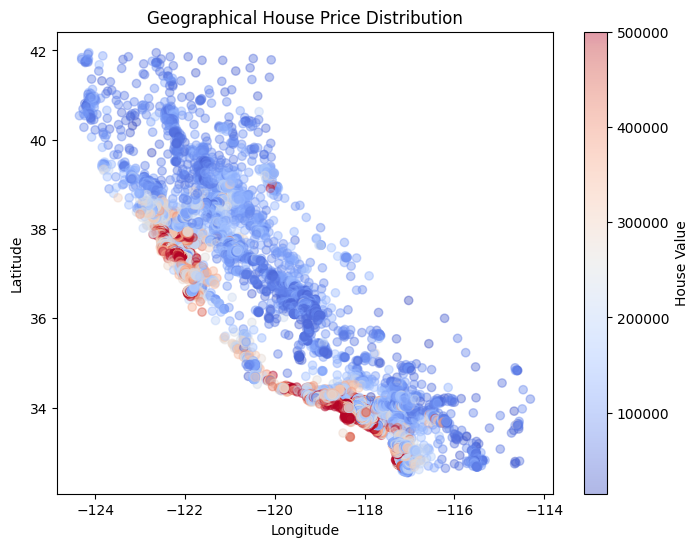

In [18]:
# Location plot
plt.figure(figsize=(8,6))
plt.scatter(df["longitude"], df["latitude"],
            c=df["median_house_value"], cmap="coolwarm", alpha=0.4)
plt.colorbar(label="House Value")
plt.title("Geographical House Price Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [20]:
print("EDA Completed Successfully!")

EDA Completed Successfully!


In [21]:
df.to_csv("cleaned_housing.csv", index=False)